# 1) Simple EOS Tutorial from ASE https://wiki.fysik.dtu.dk/ase/tutorials/eos/eos.html

In [71]:
import numpy as np
from ase.build import bulk
from ase import Atoms
from ase.calculators.emt import EMT
from ase.io.trajectory import Trajectory
import os 
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_PLACES"] = "cores"
os.environ["OMP_PROC_BIND"] = "close"
np.set_printoptions(precision=8, suppress=True)

a = 4.08  # approximate lattice constant
b = a / 2
ag = Atoms('Ag',
           cell=[(0, b, b), (b, 0, b), (b, b, 0)],
           pbc=1)  # use EMT potential, The EMT potential is included in the ASE package in order to have a simple calculator that can be used for quick demonstrations and tests.

In [72]:
V_g = 4.08**3
print(V_g/4)

16.979328000000002


In [73]:
ag.calc=EMT()

In [74]:
from ase.visualize import view
view(ag, viewer='ngl')

In [75]:
print(ag.calc)

In [76]:
cell = ag.get_cell()
print(cell)

Cell([[0.0, 2.04, 2.04], [2.04, 0.0, 2.04], [2.04, 2.04, 0.0]])


In [77]:
traj = Trajectory('Ag.traj', 'w')

In [78]:
for x in np.linspace(0.95, 1.05, 6):
    ag.set_cell(cell * x, scale_atoms=True)
    print(x, ag.get_cell())

0.95 Cell([[0.0, 1.938, 1.938], [1.938, 0.0, 1.938], [1.938, 1.938, 0.0]])
0.97 Cell([[0.0, 1.9788, 1.9788], [1.9788, 0.0, 1.9788], [1.9788, 1.9788, 0.0]])
0.99 Cell([[0.0, 2.0196, 2.0196], [2.0196, 0.0, 2.0196], [2.0196, 2.0196, 0.0]])
1.01 Cell([[0.0, 2.0604, 2.0604], [2.0604, 0.0, 2.0604], [2.0604, 2.0604, 0.0]])
1.03 Cell([[0.0, 2.1012, 2.1012], [2.1012, 0.0, 2.1012], [2.1012, 2.1012, 0.0]])
1.05 Cell([[0.0, 2.1420000000000003, 2.1420000000000003], [2.1420000000000003, 0.0, 2.1420000000000003], [2.1420000000000003, 2.1420000000000003, 0.0]])


In [79]:
for x in np.linspace(0.95, 1.05, 6):
    ag.set_cell(cell * x, scale_atoms=True)
    ag.get_potential_energy()
    traj.write(ag)

This will write a trajectory file containing five configurations of FCC silver for five different lattice constants. Now, analyse the result with the EquationOfState class and this script:

In [80]:
from ase.units import Bohr,Rydberg,kJ,kB,fs,Hartree,mol,kcal
print(Bohr, Rydberg)

0.5291772105638411 13.605693012183622


In [81]:
from ase.eos import EquationOfState
from ase.io import read, write
from ase.units import kJ

for i in read('Ag.traj@0:6'):
    print(i.get_volume(), ag.get_potential_energy())

14.557651343999998 0.11377812131535503
15.496574223743995 0.11377812131535503
16.475024979072003 0.11377812131535503
17.493818617728 0.11377812131535503
18.553770147456 0.11377812131535503
19.65569457600001 0.11377812131535503


In [82]:
configs = read('Ag.traj@0:6')  # read 5 configurations
# Extract volumes and energies:
volumes = [ag.get_volume() for ag in configs]
energies = [ag.get_potential_energy() for ag in configs]

In [83]:
print(volumes, energies)

[14.557651343999998, 15.496574223743995, 16.475024979072003, 17.493818617728, 18.553770147456, 19.65569457600001] [0.11901809746996417, 0.03499985772588676, 0.0013662577761595074, 0.008522314540340581, 0.04822077523937818, 0.11377812131535503]


In [84]:
eos = EquationOfState(volumes, energies, eos="murnaghan")

In [85]:
print(eos.getplotdata())

('murnaghan', -0.00017504510227685363, 16.775140954516107, 0.6163157539564531, array([14.55765134, 14.60914673, 14.66064212, 14.7121375 , 14.76363289,
       14.81512827, 14.86662366, 14.91811905, 14.96961443, 15.02110982,
       15.07260521, 15.12410059, 15.17559598, 15.22709136, 15.27858675,
       15.33008214, 15.38157752, 15.43307291, 15.4845683 , 15.53606368,
       15.58755907, 15.63905445, 15.69054984, 15.74204523, 15.79354061,
       15.845036  , 15.89653138, 15.94802677, 15.99952216, 16.05101754,
       16.10251293, 16.15400832, 16.2055037 , 16.25699909, 16.30849447,
       16.35998986, 16.41148525, 16.46298063, 16.51447602, 16.56597141,
       16.61746679, 16.66896218, 16.72045756, 16.77195295, 16.82344834,
       16.87494372, 16.92643911, 16.97793449, 17.02942988, 17.08092527,
       17.13242065, 17.18391604, 17.23541143, 17.28690681, 17.3384022 ,
       17.38989758, 17.44139297, 17.49288836, 17.54438374, 17.59587913,
       17.64737451, 17.6988699 , 17.75036529, 17.80186067

In [86]:
v0, e0, B = eos.fit()
print(v0, e0, B / kJ * 1.0e24, 'GPa')

16.775140954516107 -0.00017504510227685363 98.74466920197541 GPa


<Axes: title={'center': 'murnaghan: E: -0.000 eV, V: 16.775 Å$^3$, B: 98.745 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

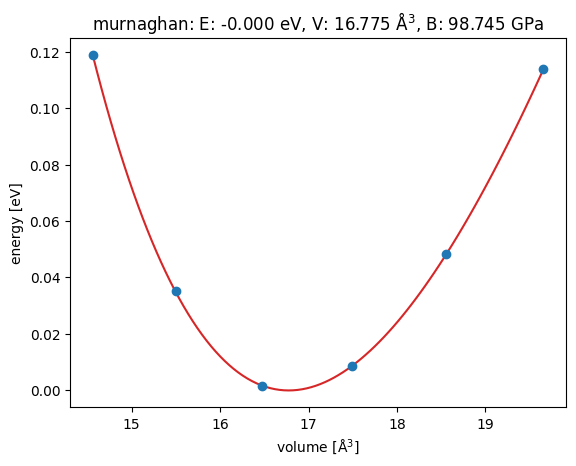

In [87]:
eos.plot('Ag-eos.png')

# In class project: 

1. Calculate the lattice parameter at equillibrium from the above.

2. Visualise using the built in visualiser, the lattice as a function of the strain (animation)?

3. We will devide into groups, each will  visit [the ASE EOS documentation](https://wiki.fysik.dtu.dk/ase/ase/eos.html#ase.eos.EquationOfState) and will be assigned one or more EOS forms. Each group will calculate the lattice parameter with a different EOS.

compare v0, e0, B (live table on the board or /public). 

Go to https://wiki.fysik.dtu.dk/ase/ase/eos.html#ase.eos.EquationOfState and see different types of EOS!

# Lattice constants for HCP Ni (Ni is FCC!) 
This is from teh official [ASE tutorial](https://ase-lib.org/tutorials/lattice_constant.html) but modified.

see also https://materials.springer.com/isp/crystallographic/docs/sd_0529814 and https://next-gen.materialsproject.org/materials/mp-79?formula=Zn

Note an HCP crystal has two lattice parameters $a$ and $b$. 
##### !!!!   We use the ASE EMT potential below just for pedagogical reasons, DO NOT USE IT FOR PRODUCTION!

In [107]:
a0 = 3.5 / np.sqrt(2)
c0 = np.sqrt(8 / 3.0) * a0

In [113]:
ni_traj = Trajectory('Ni.traj', 'w')
eps = 0.01
for a in a0 * np.linspace(1 - eps, 1 + eps, 3):
    for c in c0 * np.linspace(1 - eps, 1 + eps, 3):
        ni = bulk('Ni', 'hcp', a=a, c=c)
        ni.calc = EMT()
        ni.get_potential_energy()
        ni_traj.write(ni)


In [114]:
configs = read('Ni.traj@:')
energies = [config.get_potential_energy() for config in configs]
a = np.array([config.cell[0, 0] for config in configs])
c = np.array([config.cell[2, 2] for config in configs])
volumes = np.array(a**2 * c)

In [115]:
print(volumes, volumes.shape, a.shape, c.shape)

[24.01867742 24.26129032 24.50390323 24.50635386 24.75389279 25.00143172
 24.99893158 25.25144604 25.5039605 ] (9,) (9,) (9,)


In [116]:
print(c)

[4.00103737 4.04145188 4.0818664  4.00103737 4.04145188 4.0818664
 4.00103737 4.04145188 4.0818664 ]


In [117]:
print(a/c)

[0.61237244 0.60624871 0.60024625 0.61855802 0.61237244 0.60630934
 0.6247436  0.61849616 0.61237244]


Practical / pragmatic approach, no physical reason, just a quadratic function, a Taylor expansion of the energy surface $E(a, c)$ around the minimum
$$E(a, c) = p_0 + p_1 a + p_2 c + p_3 a^2 + p_4 ac + p_5 c^2$$

In [118]:
functions = np.array([a**0, a, c, a**2, a * c, c**2])
# this is [1 a c a^2 ac c^2], the "basis" of the polynomial. 

In [119]:
functions.shape


(6, 9)

In [120]:
# explain why this is the shape?

In [121]:
import matplotlib.pyplot as plt

def E(a, c):
    """
    Quadratic polynomial: E(a, c).
    """
    E = a+ c + a**2 + a*c + c**2 
    return E

a_min, a_max = -1, 0.4
c_min, c_max = -1, 0.4
N = 50

A = np.linspace(a_min, a_max, N)
C = np.linspace(c_min, c_max, N)
A, C = np.meshgrid(A, C)

E = E(A, C)

In [122]:
#print(E)

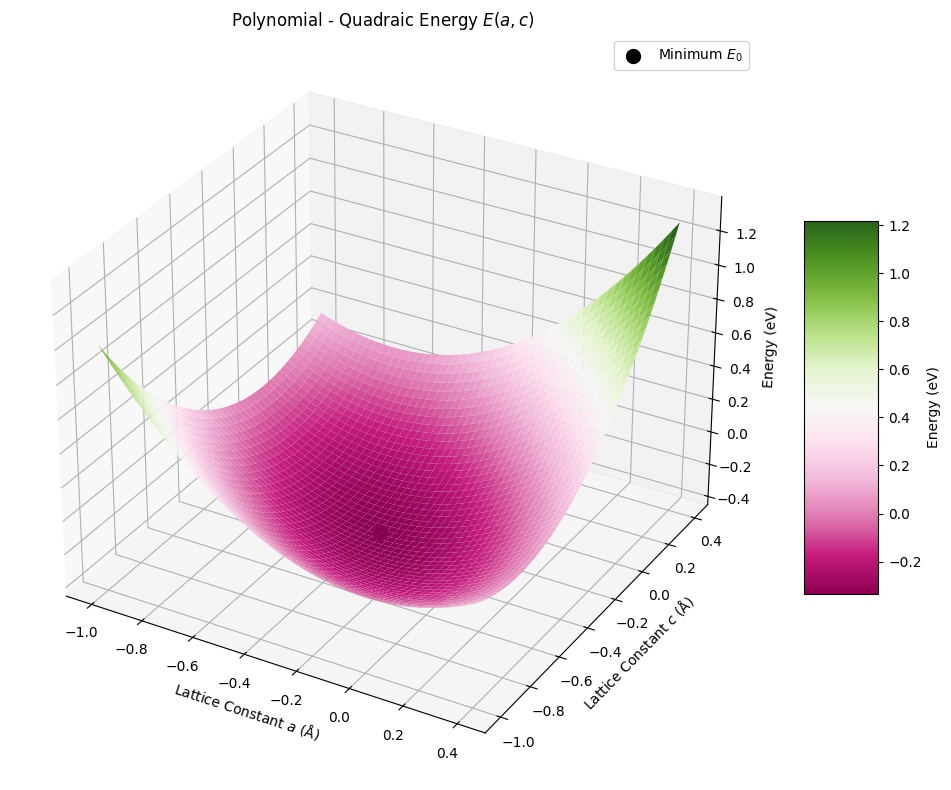

In [123]:
fig_E_surface = plt.figure(figsize=(10, 8))
ax = fig_E_surface.add_subplot(111, projection='3d')

surf = ax.plot_surface(A, C, E, cmap='PiYG', edgecolor='none')
# see https://matplotlib.org/stable/users/explain/colors/colormaps.html
ax.set_xlabel(r'Lattice Constant $a$ ($\mathrm{\AA}$)')
ax.set_ylabel(r'Lattice Constant $c$ ($\mathrm{\AA}$)')
ax.set_zlabel('Energy (eV)')
ax.set_title(r'Polynomial - Quadraic Energy $E(a, c)$')

fig_E_surface.colorbar(surf, shrink=0.5, aspect=5, label='Energy (eV)')

ax.scatter([-1./3.], [-1./3.], [-1./3.], color='black', s=100, label='Minimum $E_0$')
ax.legend()

plt.tight_layout()
plt.savefig('E_a_c_polynomial_fit.png')
# plt.show()

In [124]:
#https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html 
p = np.linalg.lstsq(functions.T, energies, rcond=-1)[0]
p0 = p[0]
p1 = p[1:3]
p2 = np.array([(2 * p[3], p[4]), (p[4], 2 * p[5])])
a0, c0 = np.linalg.solve(p2.T, -p1)
# explain the above! what are we solving for here?
with open('lattice_constant.csv', 'w') as fd:
    fd.write(f'{a0:.3f}, {c0:.3f}\n')

print(f'{a0:.3f}, {c0:.3f}\n')

2.466, 4.024



In [125]:
# Optional (formative): check out this https://ase-lib.org/tutorials/lattice_constant.html#using-the-stress-tensor